Synthesize Criteo data using sequential CART models. (Note that this file uses the updated synthesis and optimization functions from the `helper_functions.py` file.).

In [1]:
import matplotlib.pyplot as plt
import sys

# Add the parent directory to path
sys.path.append('..')

# Then import
from helper_functions import *

rng = np.random.RandomState(42)

Import Criteo data (small version for testing)

In [2]:
train_data = pd.read_csv("../../Data/Criteo/cleaned_criteo_train_os.gz",
                         compression='gzip', 
                         sep='\,',
                         header=0,
                         engine='python')
                         
data_set = "train_os"

In [6]:
train_data.to_csv("../../Data/Criteo/cleaned_criteo_train_os.csv", index=False)

View confidential data to synthesize.

In [3]:
train_data

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,24.352730,10.059654,9.002550,4.679882,10.280525,4.115453,-9.404879,4.833815,3.892853,13.190056,5.300375,-0.168679,1,0,0,0
1,20.027816,10.059654,8.653796,3.359763,14.339694,4.115453,-9.864621,4.833815,3.781017,35.805995,5.916066,-0.473542,0,1,1,0
2,21.787905,10.059654,8.440707,4.679882,10.280525,4.115453,-8.493011,4.833815,3.842828,29.214161,5.300375,-0.168679,1,0,0,0
3,13.954588,10.059654,8.214851,-1.072603,10.280525,4.115453,-11.495164,4.833815,3.863287,33.213193,5.300375,-0.168679,1,1,1,1
4,23.970150,10.059654,8.214383,4.679882,10.280525,3.013064,-11.398781,10.591158,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61156,24.941363,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
61157,23.106934,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
61158,25.975578,10.059654,8.475106,4.679882,11.561050,4.115453,-2.411115,4.833815,3.835851,23.570168,6.034478,-0.168679,1,1,1,0
61159,23.131460,10.059654,8.634955,4.679882,10.280525,4.115453,-5.576414,4.833815,3.880455,16.226044,5.300375,-0.168679,1,1,1,0


How many control group observations do we have?

In [4]:
np.mean(train_data.treatment == 0) * train_data.shape[0]

np.float64(7676.0)

Set up dictionary of parameter bounds for the Bayesian optimization process. The current state of the code requires a set of bounds for each parameter being optimized.

In [5]:
# define some default bounds for leaf values. These will be appropriately filled in during the loop below

param_bounds = {
    'tree': {
        'f0': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [10, 1000]  # [min, max] bounds
        },
        'f1': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [5, 5]  # [min, max] bounds
        },
        'f2': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [5, 5]  # [min, max] bounds
        },
        'f3': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [10, 1000]  # [min, max] bounds
        },
        'f4': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [5, 5]  # [min, max] bounds
        },
        'f5': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [10, 1000]  # [min, max] bounds
        },
        'f6': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [10, 1000]  # [min, max] bounds
        },
        'f7': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [5, 5]  # [min, max] bounds
        },
        'f8': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [4063, 10000]  # [min, max] bounds
        },
        'f9': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [5, 5]  # [min, max] bounds
        },
        'f10': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [5, 5]  # [min, max] bounds
        },
        'f11': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [10, 1000]  # [min, max] bounds
        }
    }
}

In [6]:
min_bound = 5

synthesis_cols, synthesis_steps, synthesis_bounds = define_synthesis_steps(train_data = train_data, 
                                                                           current_param_bounds=param_bounds,
                                                                           lower_bound=min_bound)

In [7]:
synthesis_cols

['treatment',
 'exposure',
 'visit',
 'conversion',
 'f8',
 'f9',
 'f3',
 'f4',
 'f6',
 'f5',
 'f11',
 'f1',
 'f10',
 'f0',
 'f7',
 'f2']

In [8]:
synthesis_steps

[(['treatment', 'exposure', 'visit', 'conversion'], 'joint_categorical'),
 (['f8', 'f9', 'f3', 'f4', 'f6', 'f5', 'f11', 'f1', 'f10', 'f0', 'f7', 'f2'],
  'tree')]

In [9]:
synthesis_bounds

{'tree': {'f0': {'min_samples_leaf': [5, 30580]},
  'f1': {'min_samples_leaf': [5, 5]},
  'f2': {'min_samples_leaf': [5, 5]},
  'f3': {'min_samples_leaf': [5, 30580]},
  'f4': {'min_samples_leaf': [5, 30580]},
  'f5': {'min_samples_leaf': [5, 30580]},
  'f6': {'min_samples_leaf': [5, 30580]},
  'f7': {'min_samples_leaf': [5, 30580]},
  'f8': {'min_samples_leaf': [177, 30580]},
  'f9': {'min_samples_leaf': [5, 30580]},
  'f10': {'min_samples_leaf': [5, 5]},
  'f11': {'min_samples_leaf': [5, 30580]}}}

Define additional parameters of the optimization process:

- num_synthetic_datasets: Number of synthetic datasets to generate on each iteration of the optimizer (usually use 10 to reduce compute time)
- num_iter_optimization: Number of iterations to run the optimizer (default is 25, can run longer to try to find a better solution)
- num_init_optimization: Number of initializations to perform prior to optimized iterations (usually 3-5, this just starts the optimizer)
- random_states: run the optimizer all the way through for each random seed in this list

In [10]:
number_synthetic_datasets = 10
num_iter_optimization = 25
num_init_optimization = 5
random_states = [1006, 428]

Compute target uplift distribution.

In [11]:
# reorder the columns in the training data to match the synthesis order
train_data = train_data[synthesis_cols]

In [12]:
train_data

,treatment,exposure,visit,conversion,f8,f9,f3,f4,f6,f5,f11,f1,f10,f0,f7,f2
0,1,0,0,0,3.892853,13.190056,4.679882,10.280525,-9.404879,4.115453,-0.168679,10.059654,5.300375,24.352730,4.833815,9.002550
1,0,0,1,1,3.781017,35.805995,3.359763,14.339694,-9.864621,4.115453,-0.473542,10.059654,5.916066,20.027816,4.833815,8.653796
2,1,0,0,0,3.842828,29.214161,4.679882,10.280525,-8.493011,4.115453,-0.168679,10.059654,5.300375,21.787905,4.833815,8.440707
3,1,1,1,1,3.863287,33.213193,-1.072603,10.280525,-11.495164,4.115453,-0.168679,10.059654,5.300375,13.954588,4.833815,8.214851
4,1,0,0,0,3.971858,13.190056,4.679882,10.280525,-11.398781,3.013064,-0.168679,10.059654,5.300375,23.970150,10.591158,8.214383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61156,1,0,0,0,3.971858,13.190056,4.679882,10.280525,-2.411115,4.115453,-0.168679,10.059654,5.300375,24.941363,4.833815,8.214383
61157,1,0,0,0,3.971858,13.190056,4.679882,10.280525,-1.288207,4.115453,-0.168679,10.059654,5.300375,23.106934,4.833815,8.214383
61158,1,0,1,1,3.835851,23.570168,4.679882,11.561050,-2.411115,4.115453,-0.168679,10.059654,6.034478,25.975578,4.833815,8.475106
61159,1,0,1,1,3.880455,16.226044,4.679882,10.280525,-5.576414,4.115453,-0.168679,10.059654,5.300375,23.131460,4.833815,8.634955


In [13]:
feature_cols = [f"f{i}" for i in range(12)]

def compute_uplift_distribution(df, feature_cols = feature_cols, treatment_col="treatment", outcome_col="conversion"):
    treat_df   = df[df[treatment_col] == 1]
    control_df = df[df[treatment_col] == 0]
    X_treat   = treat_df[feature_cols]
    y_treat   = treat_df[outcome_col]
    X_control = control_df[feature_cols]
    y_control = control_df[outcome_col]

    model_t = LogisticRegression(penalty=None, max_iter=1000)
    model_c = LogisticRegression(penalty=None, max_iter=1000)
    model_t.fit(X_treat, y_treat)
    model_c.fit(X_control, y_control)

    X_all = df[feature_cols]
    p_t = model_t.predict_proba(X_all)[:, 1]
    p_c = model_c.predict_proba(X_all)[:, 1]

    uplift = p_t - p_c
    return uplift

In [14]:
target_uplift = compute_uplift_distribution(df = train_data, feature_cols = feature_cols)

C:\Users\Cam\anaconda3\envs\optimized-sequential-synthesis\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
target_uplift

array([0.0660087 , 0.00040655, 0.12254014, ..., 0.09262261, 0.07012455, 0.02334493])

Use the `optimization_models` function to perform the optimized synthesis process. The function returns the objective value associated with each iteration, the best set of parameters for each random seed, and the final optimization object from the Bayesian optimization function.

In [16]:
# import warnings
# warnings.filterwarnings('ignore')

# we are silencing harmless overflow warnings from numpy related to the Yeo-johnson transformation
# these warnings are not related to the optimization process and can be safely ignored

optimization_results = [optimize_models_with_param_target(train_data=train_data,
                                                          number_synthetic_datasets=number_synthetic_datasets,
                                                          synthesis_steps=synthesis_steps,
                                                          param_bounds=synthesis_bounds,
                                                          random_state=r,
                                                          target_uplift_distribution=target_uplift,
                                                          n_iter=num_iter_optimization,
                                                          n_init=num_init_optimization) for r in random_states]

Optimizing 12 parameters: ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11']
|   iter    |  target   |    x0     |    x1     |    x2     |    x3     |    x4     |    x5     |    x6     |    x7     |    x8     |    x9     |    x10    |    x11    |
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
| 1         | -0.009918 | 22726.119 | 5.0       | 5.0       | 26983.018 | 22651.864 | 22057.633 | 9035.2601 | 16072.663 | 5459.9628 | 24830.652 | 5.0       | 7848.1032 |
| 2         | -0.010327 | 7258.4432 | 5.0       | 5.0       | 6181.4723 | 30050.452 | 29990.775 | 22471.628 | 12519.500 | 18990.717 | 2427.3595 | 5.0       | 18515.747 |
| 3         | -0.010027 | 13778.640 | 5.0       | 5.0       | 8841.9900 | 30433.515 | 24977.980 | 8108.2850 | 10952.299 | 20537.453 | 28307.856 | 5.0       | 25571.007 |
| 4         | -0.009894 | 6234.7453 | 5.0       |

In [17]:
run_targets = [np.minimum.accumulate(-i['optimizer'].space.target) for i in optimization_results]

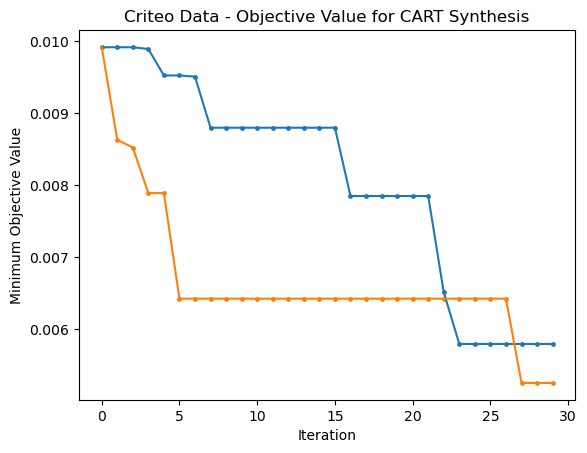

In [18]:
fig = plt.figure()
plt.plot(run_targets[0])
plt.scatter(np.arange(len(run_targets[0])), run_targets[0], s=6)
plt.plot(run_targets[1])
plt.scatter(np.arange(len(run_targets[1])), run_targets[1], s=6)
plt.title("Criteo Data - Objective Value for CART Synthesis")
plt.xlabel("Iteration")
plt.ylabel("Minimum Objective Value")
plt.show()

In [19]:
optimization_results

[{'best_params': {'gmm': {},
   'multinomial': {},
   'tree': {'f8': {'min_samples_leaf': np.float64(9982.664920205403)},
    'f9': {'min_samples_leaf': np.float64(5.0)},
    'f3': {'min_samples_leaf': np.float64(5.0)},
    'f4': {'min_samples_leaf': np.float64(579.4558016638935)},
    'f6': {'min_samples_leaf': np.float64(23705.03826643696)},
    'f5': {'min_samples_leaf': np.float64(4333.741763864174)},
    'f11': {'min_samples_leaf': np.float64(17216.75216988239)},
    'f1': {'min_samples_leaf': np.float64(7610.548631736712)},
    'f10': {'min_samples_leaf': np.float64(16869.313314689698)},
    'f0': {'min_samples_leaf': np.float64(6029.726191165025)},
    'f7': {'min_samples_leaf': np.float64(5.0)},
    'f2': {'min_samples_leaf': np.float64(29928.258198787466)}}},
  'best_score': np.float64(0.005797910820477018),
  'optimizer': <bayes_opt.bayesian_optimization.BayesianOptimization at 0x202e7683b90>},
 {'best_params': {'gmm': {},
   'multinomial': {},
   'tree': {'f8': {'min_samples

In [20]:
best_params = optimization_results[np.argmin([x['best_score'] for x in optimization_results])]['best_params']

In [21]:
best_state = random_states[np.argmin([x['best_score'] for x in optimization_results])]

In [22]:
# warnings.filterwarnings('ignore')

# again, we are silencing harmless overflow warnings from numpy related to the Yeo-johnson transformation

wassersteins, full_sXs = perform_synthesis_with_param_target(
    train_data=train_data,
    number_synthetic_datasets=20,
    synthesis_steps=synthesis_steps,
    target_uplift_distribution=target_uplift,
    param_values=best_params,
    random_state=best_state,
    target_variable=None,
    exog_variables=None
)

In [23]:
np.mean(wassersteins)

np.float64(0.005778695274415385)

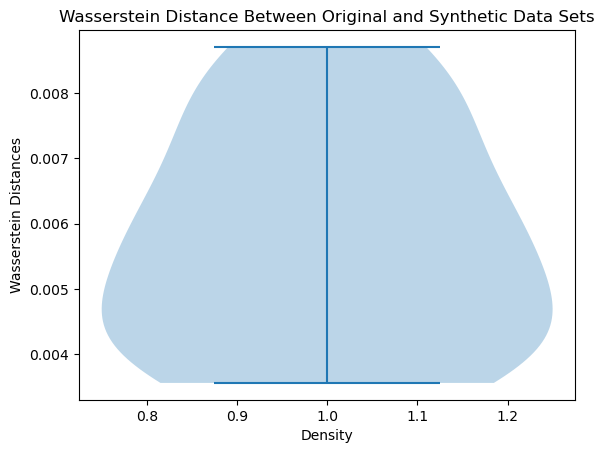

In [24]:
plt.violinplot(wassersteins)
plt.xlabel("Density")
plt.ylabel("Wasserstein Distances")
plt.title("Wasserstein Distance Between Original and Synthetic Data Sets")
plt.show()

In [26]:
synthetic_data_path = "../../Data/Criteo/"

for i, sX in enumerate(full_sXs):
    if not os.path.exists(synthetic_data_path):
        os.makedirs(synthetic_data_path)
    sX.to_csv(synthetic_data_path + "cart_" + str(i) + "_" + data_set + "_uplift.csv", index=False)

End of file.